In [2]:
# Importación de librerias
from langgraph.graph import START, END, StateGraph
from langgraph.types import Command
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from dotenv import load_dotenv, find_dotenv
from typing import TypedDict, Optional, Dict, List, Literal, Annotated
from operator import add
from IPython.display import Image, display
from prompt_toolkit.search import SearchState
from twisted.conch.ssh.connection import messages

In [25]:
# Carga de variables de entorno
dotenv_path = find_dotenv()
load_dotenv(dotenv_path)


True

In [26]:
# Modelo utilizado
llm = ChatOpenAI(model="gpt-4o")

In [27]:
# Creación del estado
class GlobalState(TypedDict): # Estado Globa
    graph: str
    messages: list[dict] # Es una lista de diccionarios
    next: str
    
class SearchState(TypedDict):
    search: List[dict]

In [28]:
# Miembros del equipo
members = ["researcher"]
options = members + ["FINISH"]

In [29]:
# Router con opciones para el llm
class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""

    next: Literal["researcher", "FINISH"]

In [64]:
system_prompt =(
    "Eres un supervisor encargado de gestionar una conversación entre los"
    f" siguientes trabajadores: {members}. Dada la siguiente solicitud del usuario,"
    " responde con el trabajador que debe actuar a continuación. Cada trabajador"
    " realizará una tarea y responderá con sus resultados y estado. Cuando termine,"
    " responde con FINISH."
)

In [65]:
def supervisor_node(state: GlobalState) -> Command[Literal["researcher", "__end__"]]:
    messages = [{"role":"system", "content":system_prompt},] + state["messages"]
    response = llm.with_structured_output(Router).invoke(messages)
    goto = response["next"]
    print("DIRIGIENDO FLUJO A: ", goto)
    if goto == "FINISH":
        goto = END
    
    return Command(goto=goto, update = {"next":goto})

In [66]:
# Tool de search node
tavily_tool = TavilySearchResults(max_results=1)
research_agent = create_react_agent(
    llm, tools=[tavily_tool], prompt="Eres un agente especializado en busqueda web."
)

In [67]:
def search_node(state: GlobalState) -> Command[Literal["supervisor"]]:
    result = research_agent.invoke(state)
    # print("DEBUG result: ", result)  # <-- esto

    return Command(goto="supervisor", 
                   update = {
                       "__state__": {"search":result["messages"]},"messages":result["messages"]})

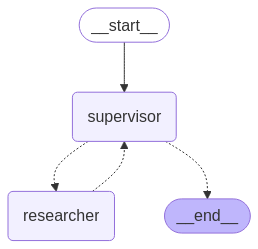

In [68]:
builder = StateGraph(GlobalState)
builder.add_edge(START, "supervisor")
builder.add_node("supervisor", supervisor_node)
builder.add_node("researcher",search_node)

graph =  builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [73]:
sal = graph.invoke({"messages":["Busca en internet quien es el actual presidente de los Estados Unidos de América"]})
for m in sal['messages']:
   m.pretty_print() 

DIRIGIENDO FLUJO A:  researcher
DIRIGIENDO FLUJO A:  FINISH
================================ Human Message =================================

Busca en internet quien es el actual presidente de los Estados Unidos de América
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_A5KFigyU2r7l0lgXIBxqBAb5)
 Call ID: call_A5KFigyU2r7l0lgXIBxqBAb5
  Args:
    query: actual presidente de los Estados Unidos Octubre 2023
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Noticias de Estados Unidos - Voz de América - Voz de América", "url": "https://www.vozdeamerica.com/estados-unidos/2023/10/19", "content": "El presidente de EEUU, Joe Biden, se dirigió a la nación para abordar la. octubre 19, 2023. Biden recalca la \"vital importancia\" de Israel y", "score": 0.854509}]
================================== Ai Message =================================